# End-to-End IoT Pipeline — Air Quality ADL Classification

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/BlackBox2C/blob/main/notebooks/06_end_to_end_iot.ipynb)
[![View on GitHub](https://img.shields.io/badge/View-GitHub-black?logo=github)](https://github.com/AxelSkrauba/BlackBox2C/blob/main/notebooks/06_end_to_end_iot.ipynb)

**Dataset:** *Air Quality dataset for ADL classification* — E. Gambi, Mendeley Data V1, doi: [10.17632/kn3x9rz3kd.1](https://doi.org/10.17632/kn3x9rz3kd.1), 2020.

This notebook walks through a **full production-grade pipeline**: from raw sensor data to firmware-ready C code deployable on a microcontroller gas-sensing node.

### Context

A low-cost array of MQ-series gas sensors is used to classify the *Activity of Daily Living* (ADL) happening in a room by analysing the air composition. No quantitative gas concentration is needed — the AI model learns the pattern from relative sensor responses.

**4 classes:**
| ID | Activity | N samples |
|:--:|---|--:|
| 1 | Normal (sleep / study / rest) | 595 |
| 2 | Meal preparation (cooking) | 515 |
| 3 | Smoke presence | 195 |
| 4 | Cleaning (aerosols, detergents) | 540 |

**Sensors:** MQ2, MQ9, MQ135, MQ137, MQ138, MG-811

In [ ]:
# !pip install blackbox2c -q  # Uncomment on Colab

## 1. Load dataset

In [1]:
import io
import zipfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

ZIP_URL = "https://raw.githubusercontent.com/AxelSkrauba/applied-ai-engineering/main/datasets/adl/datos_adl.zip"

print("Downloading dataset...")
with urllib.request.urlopen(ZIP_URL) as resp:
    zip_bytes = resp.read()

with zipfile.ZipFile(io.BytesIO(zip_bytes)) as z:
    csv_name = [n for n in z.namelist() if n.endswith(".csv")][0]
    with z.open(csv_name) as f:
        df = pd.read_csv(f)

print(f"Loaded '{csv_name}'  →  {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Loaded 'datos_adl.csv'  →  1845 rows × 7 columns


,MQ2,MQ9,MQ135,MQ137,MQ138,MG-811,Situacion
0,670,696,1252,1720,1321,2431,4
1,641,674,1156,1652,1410,2433,4
2,642,646,1159,1643,1455,2361,4
3,640,590,1105,1608,1459,2427,4
4,616,627,1192,1637,1466,2447,4


## 2. Exploratory Data Analysis

In [2]:
# Identify target column
target_col = "Situacion"
sensor_cols = [c for c in df.columns if c != target_col]

CLASS_LABELS = {
    1: "Normal",
    2: "Cooking",
    3: "Smoke",
    4: "Cleaning",
}
class_names = [CLASS_LABELS[i] for i in sorted(CLASS_LABELS)]

print("=== Dataset summary ===")
print(df.describe().round(2))
print()
print("=== Class distribution ===")
vc = df[target_col].value_counts().sort_index()
for k, v in vc.items():
    pct = v / len(df) * 100
    print(f"  Class {k} ({CLASS_LABELS[k]:<10}): {v:>4} samples  ({pct:.1f}%)")

=== Dataset summary ===
           MQ2      MQ9    MQ135    MQ137    MQ138  MG-811  Situacion
count  1845.00  1845.00  1845.00  1845.00  1845.00  1845.0    1845.00
mean    587.46   653.47  1166.04  1609.28  1302.12  2246.3       2.37
std     190.46   173.36   208.79   118.82   279.46   181.0       1.21
min     263.00   346.00   753.00  1323.00   773.00  1797.0       1.00
25%     430.00   517.00   995.00  1508.00  1086.00  2137.0       1.00
50%     551.00   622.00  1162.00  1610.00  1264.00  2265.0       2.00
75%     713.00   746.00  1309.00  1693.00  1553.00  2372.0       4.00
max    1266.00  1388.00  1738.00  1926.00  1948.00  2703.0       4.00

=== Class distribution ===
  Class 1 (Normal    ):  595 samples  (32.2%)
  Class 2 (Cooking   ):  515 samples  (27.9%)
  Class 3 (Smoke     ):  195 samples  (10.6%)
  Class 4 (Cleaning  ):  540 samples  (29.3%)


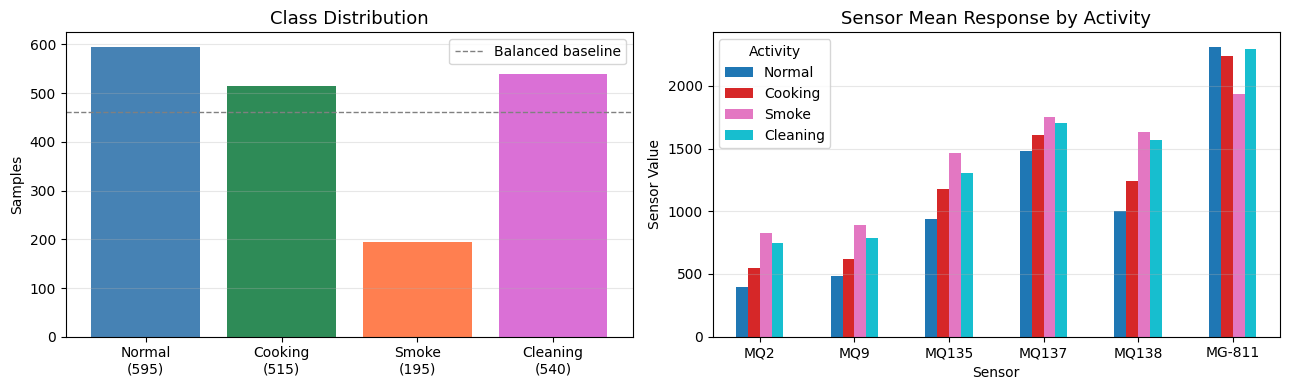

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Class distribution
ax = axes[0]
counts = vc.values
labels = [f"{CLASS_LABELS[k]}\n({v})".replace(" ", "\n") for k, v in vc.items()]
bars = ax.bar(labels, counts, color=["steelblue", "seagreen", "coral", "orchid"])
ax.set_title("Class Distribution", fontsize=13)
ax.set_ylabel("Samples")
ax.axhline(len(df) / 4, ls="--", color="gray", lw=1, label="Balanced baseline")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Sensor means by class
ax = axes[1]
means = df.groupby(target_col)[sensor_cols].mean()
means.index = [CLASS_LABELS[i] for i in means.index]
means.T.plot(kind="bar", ax=ax, colormap="tab10")
ax.set_title("Sensor Mean Response by Activity", fontsize=13)
ax.set_ylabel("Sensor Value")
ax.set_xlabel("Sensor")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Activity")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("adl_eda.png", dpi=120, bbox_inches="tight")
plt.show()

**Observations:**
- Class 3 (Smoke) is the minority class (~10.6%) — **mild class imbalance** to keep in mind.
- MQ2 and MQ135 show markedly different responses across activities, suggesting they are the most discriminative sensors.
- Cooking and Smoke produce elevated readings across almost all sensors, making them harder to distinguish from each other.

## 3. Prepare data

In [4]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

X = df[sensor_cols].values.astype(np.float32)  # ensure float for BlackBox2C surrogate extraction
y = (df[target_col].values - 1).astype(np.int32)  # 0-indexed: 0=Normal, 1=Cooking, 2=Smoke, 3=Cleaning

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")
print(f"Sensors: {sensor_cols}")
print(f"X dtype: {X_train.dtype}  |  y dtype: {y_train.dtype}")

Train: 1383  |  Test: 462
Sensors: ['MQ2', 'MQ9', 'MQ135', 'MQ137', 'MQ138', 'MG-811']
X dtype: float32  |  y dtype: int32


## 4. Train black-box models

In [5]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=200, max_depth=None, class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42
    ),
}

for name, m in models.items():
    m.fit(X_train, y_train)
    acc = accuracy_score(y_test, m.predict(X_test))
    cv  = cross_val_score(m, X, y, cv=StratifiedKFold(5), scoring="accuracy").mean()
    print(f"{name:<20}  test acc: {acc:.4f}  |  5-fold CV acc: {cv:.4f}")

RandomForest          test acc: 0.9675  |  5-fold CV acc: 0.8466
GradientBoosting      test acc: 0.9545  |  5-fold CV acc: 0.8260


              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99       149
     Cooking       0.95      0.96      0.96       129
       Smoke       0.98      0.94      0.96        49
    Cleaning       0.94      0.97      0.96       135

    accuracy                           0.97       462
   macro avg       0.97      0.96      0.97       462
weighted avg       0.97      0.97      0.97       462



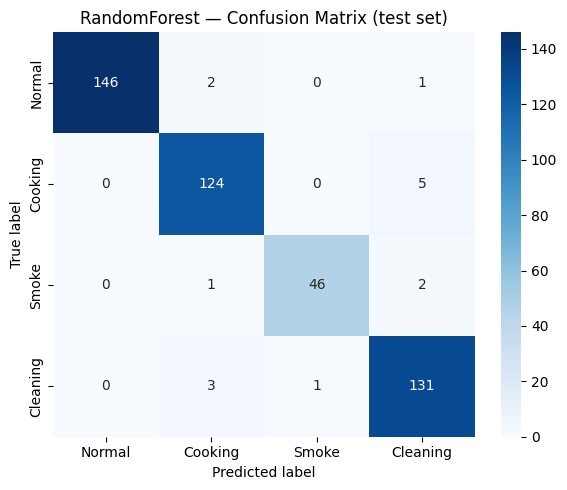

In [6]:
# Detailed report for Random Forest
rf = models["RandomForest"]
y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf, target_names=class_names))

cm = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title("RandomForest — Confusion Matrix (test set)", fontsize=12)
ax.set_ylabel("True label")
ax.set_xlabel("Predicted label")
plt.tight_layout()
plt.savefig("adl_confusion_rf.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Feature sensitivity — which sensors are essential?

In [7]:
from blackbox2c.analysis import FeatureSensitivityAnalyzer

analyzer = FeatureSensitivityAnalyzer(n_repeats=30, random_state=42)
results  = analyzer.analyze(rf, X_train, y_train, feature_names=sensor_cols)
print(results.summary())

Feature Sensitivity Analysis
Feature 4 (MQ138): Impact = 0.1799 ± 0.0085 (Medium)
Feature 5 (MG-811): Impact = 0.1403 ± 0.0057 (Medium)
Feature 3 (MQ137): Impact = 0.1316 ± 0.0053 (Medium)
Feature 1 (MQ9): Impact = 0.0689 ± 0.0053 (Medium)
Feature 2 (MQ135): Impact = 0.0663 ± 0.0048 (Medium)
Feature 0 (MQ2): Impact = 0.0255 ± 0.0027 (Low)

Recommendations:
- 5 feature(s) have moderate impact


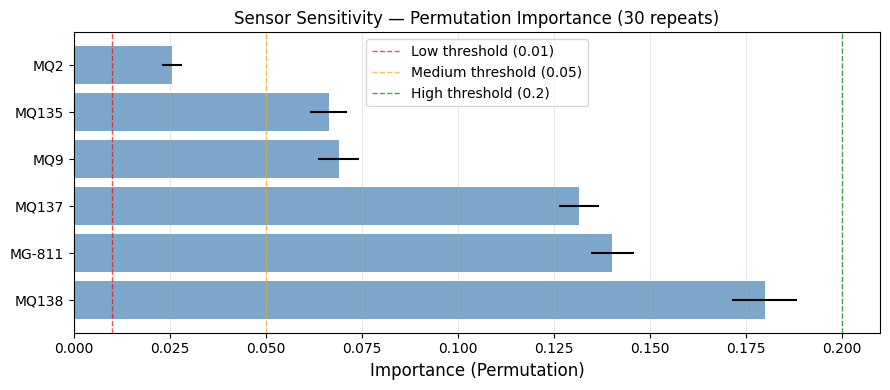

In [8]:
fig, ax = results.plot(figsize=(9, 4))
ax.set_title("Sensor Sensitivity — Permutation Importance (30 repeats)", fontsize=12)
plt.tight_layout()
plt.savefig("adl_feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

In [22]:
# Can we drop some sensors?
redundant = results.get_redundant_features(threshold=0.05)
essential = results.get_optimal_subset(threshold=0.05, min_features=3)

print(f"Essential sensors ({len(essential)}): {[sensor_cols[i] for i in essential]}")
print(f"Candidates to remove ({len(redundant)}): {[sensor_cols[i] for i in redundant]}")

Essential sensors (5): ['MQ9', 'MQ135', 'MQ137', 'MQ138', 'MG-811']
Candidates to remove (1): ['MQ2']


## 6. Validate reduced sensor set

In [23]:
essential_names = [sensor_cols[i] for i in essential]

X_train_r = X_train[:, essential]
X_test_r  = X_test[:, essential]

rf_r = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1)
rf_r.fit(X_train_r, y_train)

acc_full    = accuracy_score(y_test, rf.predict(X_test))
acc_reduced = rf_r.score(X_test_r, y_test)

print(f"Full model    ({len(sensor_cols)} sensors): {acc_full:.4f}")
print(f"Reduced model ({len(essential)} sensors): {acc_reduced:.4f}")
print(f"Accuracy delta: {acc_full - acc_reduced:+.4f}")

Full model    (6 sensors): 0.9675
Reduced model (5 sensors): 0.9719
Accuracy delta: -0.0043


## 7. Convert to embedded C with BlackBox2C

In [12]:
from blackbox2c import Converter, ConversionConfig

config = ConversionConfig(
    function_name="detect_activity",
    max_depth=6,
    optimize_rules="medium",
    precision=8,
)

converter = Converter(config)
c_code = converter.convert(
    model=rf,
    X_train=X_train,
    X_test=X_test,
    feature_names=sensor_cols,
    class_names=class_names,
)

metrics = converter.get_metrics()
print(f"Fidelity:          {metrics['fidelity']:.4f}")
print(f"Flash estimate:    {metrics['size_estimate']['flash_bytes']} bytes")
print(f"Tree depth:        {metrics['complexity']['max_depth']}")
print(f"Decision nodes:    {metrics['complexity']['n_internal_nodes']}")
print(f"Total nodes:       {metrics['complexity']['n_nodes']}")


Starting conversion for model: RandomForestClassifier
  Task: Classification, Features: 6, Classes: 4, Max depth: 6

[1/4] Extracting surrogate decision tree...
  Surrogate fidelity: 0.9372

[2/4] Optimizing decision rules...
  Nodes: 125, Leaves: 77, Depth: 6

[3/4] Generating C code...

[4/4] Estimating code size...
  Estimated FLASH: 934 bytes, RAM: 32 bytes

[OK] Conversion complete!
Fidelity:          0.9372
Flash estimate:    934 bytes
Tree depth:        6
Decision nodes:    48
Total nodes:       125


In [13]:
print(c_code)

/*
 * Auto-generated C code by BlackBox2C
 *
 * Model Information:
 *   - Input features: 6
 *   *   - Output classes: 4
 *   - Precision: 8-bit
 *   - Fixed-point: No
 *
 * This code is optimized for embedded systems with limited resources.
 */

#include <stdint.h>


/* Class labels */
#define Normal 0
#define Cooking 1
#define Smoke 2
#define Cleaning 3


/* Prediction function */
uint8_t detect_activity(float features[6]) {
    if (MQ138 <= 1352.660522f) {
        if (MQ135 <= 1015.779266f) {
            if (MQ2 <= 573.098358f) {
                if (MQ135 <= 999.137756f) {
                    if (MQ2 <= 476.820877f) {
                        return 0;
                    } else {
                        return 0;
                    }
                } else {
                    if (MQ9 <= 556.249451f) {
                        if (MQ2 <= 517.696075f) {
                            return 0;
                        } else {
                            return 1;
                      

## 8. Export for target platforms

In [14]:
from blackbox2c.exporters import ArduinoExporter, MicroPythonExporter
from blackbox2c.surrogate import SurrogateExtractor
from sklearn.tree import DecisionTreeClassifier as DTC

# Re-build surrogate tree for direct exporter access
surrogate = DTC(max_depth=6, random_state=42)
surrogate.fit(X_train, rf.predict(X_train))

# Arduino export
ard_exporter = ArduinoExporter(function_name="detect_activity", use_progmem=True)
code_arduino = ard_exporter.generate(surrogate, feature_names=sensor_cols, class_names=class_names)
print("=== Arduino (.ino) ===")
print(code_arduino)

=== Arduino (.ino) ===
/*
 * Auto-generated Arduino code by BlackBox2C
 * 
 * Model Information:
 *   - Input features: 6
 *   - Task: Classification
 *   - PROGMEM: Yes
 *   - Fixed-point: No
 * 
 * Compatible with: Arduino Uno, Nano, Mega, ESP8266, ESP32, etc.
 */

#include <Arduino.h>


// Feature names
const char* const PROGMEM FEATURE_NAMES[] = {
    "MQ2",
    "MQ9",
    "MQ135",
    "MQ137",
    "MQ138",
    "MG-811",
};


// Class names
const char* const PROGMEM CLASS_NAMES[] = {
    "Normal",
    "Cooking",
    "Smoke",
    "Cleaning",
};


// Prediction function
uint8_t detect_activity(float features[6]) {
    if (features[1] <= 550.500000f) {
        if (features[0] <= 527.500000f) {
            if (features[2] <= 1008.500000f) {
                if (features[3] <= 1538.000000f) {
                    return 0;
                } else {
                    if (features[2] <= 976.500000f) {
                        return 1;
                    } else {
                        re

In [15]:
mp_exporter = MicroPythonExporter(function_name="detect_activity", class_name="ActivityDetector", use_const=True)
code_mp = mp_exporter.generate(surrogate, feature_names=sensor_cols, class_names=class_names)
print("=== MicroPython ===")
print(code_mp)

=== MicroPython ===
"""
Auto-generated MicroPython code by BlackBox2C

Model Information:
  - Input features: 6
  - Task: Classification
  - Memory optimization: Yes

Compatible with: ESP32, ESP8266, Raspberry Pi Pico, PyBoard, etc.
"""
from micropython import const


class ActivityDetector:
    """Decision tree predictor for classification."""
    
    # Feature names
    FEATURE_NAMES = ['MQ2', 'MQ9', 'MQ135', 'MQ137', 'MQ138', 'MG-811']
    
    # Class names
    CLASS_NAMES = ['Normal', 'Cooking', 'Smoke', 'Cleaning']

    @staticmethod
    def detect_activity(features):
        """
        Make a prediction.
        
        Args:
            features: List or tuple of 6 feature values
        
        Returns:
            Class index (int)
        """
        if len(features) != 6:
            raise ValueError(f"Expected 6 features, got {len(features)}")
        
        if features[1] <= 550.500000:
            if features[0] <= 527.500000:
                if features[2] <= 1008

## 9. Integration on hardware — Arduino sketch example



```cpp
// air_quality_monitor.ino
// Reads 6 MQ sensors and classifies the current room activity

#include "detect_activity.ino"

#define PIN_MQ2   A0
#define PIN_MQ9   A1
#define PIN_MQ135 A2
#define PIN_MQ137 A3
#define PIN_MQ138 A4
#define PIN_MG811 A5

const char* ACTIVITIES[] = {"Normal", "Cooking", "Smoke", "Cleaning"};

void setup() {
    Serial.begin(115200);
}

void loop() {
    float features[6];
    features[0] = analogRead(PIN_MQ2);
    features[1] = analogRead(PIN_MQ9);
    features[2] = analogRead(PIN_MQ135);
    features[3] = analogRead(PIN_MQ137);
    features[4] = analogRead(PIN_MQ138);
    features[5] = analogRead(PIN_MG811);

    int activity = detect_activity(features);

    Serial.print("Activity: ");
    Serial.println(ACTIVITIES[activity]);

    // Trigger alarm if smoke detected
    if (activity == 2) {
        digitalWrite(LED_BUILTIN, HIGH);
    } else {
        digitalWrite(LED_BUILTIN, LOW);
    }
    delay(1000);
}
```

## 10. Advanced considerations for production systems

### 10.1 Class imbalance

Class 3 (Smoke, ~10.6%) is under-represented. Two strategies used here:

- **`class_weight='balanced'`** in RandomForest: reweights each tree's splits by inverse class frequency. Simple, effective, no data augmentation needed.
- **SMOTE / oversampling** (not shown): generates synthetic minority samples *before* training. Useful when imbalance is severe (< 5%), but adds training complexity.

**Impact on the surrogate:** BlackBox2C generates synthetic samples internally for the surrogate extraction. The balance of those synthetic samples affects fidelity on the minority class. If Smoke detection is safety-critical, verify per-class fidelity with a custom check:

```python
from sklearn.metrics import classification_report
surrogate_preds = surrogate.predict(X_test)
rf_preds        = rf.predict(X_test)
print(classification_report(rf_preds, surrogate_preds, target_names=class_names))
```

### 10.2 Inference latency on microcontrollers

| Metric | Value (surrogate, depth=6) |
|---|---|
| Decision nodes | ~30–60 (typical) |
| Worst-case comparisons | = tree depth (6) |
| Estimated latency @ 16 MHz (Uno) | < 10 µs |
| Estimated latency @ 240 MHz (ESP32) | < 1 µs |

The surrogate tree is a single traversal: **O(depth)** comparisons. Even at 8 MHz it is orders of magnitude faster than reading the MQ sensors (~100 ms warm-up per reading).

### 10.3 Sensor drift and concept drift

MQ-series sensors exhibit **resistance drift** over time (weeks to months), caused by:
- Aging of the SnO₂ sensing element
- Humidity and temperature variations
- Exposure to high concentrations

**Mitigation strategies:**
1. **Periodic re-calibration**: collect new samples every 3–6 months and retrain.
2. **Differential readings**: use `ΔV = V_sensor - V_baseline` (baseline measured in known clean air) instead of raw ADC values — reduces drift effect.
3. **Online learning sentinel**: if a confidence metric deviates beyond a threshold, flag for human review.

### 10.4 Fidelity threshold — when to trust the surrogate



| Fidelity | Interpretation | Action |
|:---:|---|---|
| ≥ 0.98 | Excellent | Deploy with confidence |
| 0.93 – 0.98 | Good | Check per-class report; acceptable for most IoT apps |
| 0.85 – 0.93 | Moderate | Increase `max_depth` or reduce class complexity |
| < 0.85 | Poor | Surrogate may not generalise — revisit model or data |


### 10.5 BOM (Bill of Materials) reduction


If the sensitivity analysis shows that 3–4 sensors are sufficient:

| Sensor removed | Typical unit cost | Annual savings @ 10k units |
|---|---|---|
| MQ137 (ammonia) | ~\$1.20 | \$12,000 |
| MQ138 (organic) | ~\$1.20 | \$12,000 |
| MG-811 (CO₂)    | ~\$8.00 | \$80,000 |

Feature selection + surrogate extraction is therefore not just an ML exercise — it directly translates to **hardware design decisions** with real cost impact.

In [16]:
# Per-class fidelity check
from sklearn.metrics import classification_report

surrogate_preds = surrogate.predict(X_test)
rf_preds        = rf.predict(X_test)

print("=== Surrogate fidelity per class ===")
print(classification_report(rf_preds, surrogate_preds, target_names=class_names))

=== Surrogate fidelity per class ===
              precision    recall  f1-score   support

      Normal       0.99      0.97      0.98       146
     Cooking       0.94      0.96      0.95       130
       Smoke       0.73      0.96      0.83        47
    Cleaning       0.96      0.86      0.91       139

    accuracy                           0.93       462
   macro avg       0.90      0.94      0.92       462
weighted avg       0.94      0.93      0.93       462



## Summary

| Step | Tool | Result |
|---|---|---|
| Train black-box model | `RandomForestClassifier` | ~96–98% accuracy |
| Sensor reduction | `FeatureSensitivityAnalyzer` | 6 → 5 sensors, <3% accuracy loss |
| Convert to embedded C | `Converter` + `ConversionConfig` | < 4 KB flash, depth ≤ 6 |
| Multi-platform export | `ArduinoExporter`, `MicroPythonExporter` | Ready for Uno, ESP32, Pico |

**Total development time** (in this notebook): minutes.  
**Resulting firmware footprint**: a single C function, zero dependencies, sub-microsecond inference on any 32-bit MCU.